## Bloque 0
Caso Guía de toda la sesión, una empresa manufacturera necesita un modelo que prediga si una maquina entrará en fallo debido a las condiciones y mediciones pasadas.

* Es un problema de clasificación binaria
* Podria estar desbalanceado

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, TimeSeriesSplit,
    cross_val_score, cross_validate, learning_curve, validation_curve,
)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, classification_report,
    mean_absolute_error, mean_absolute_percentage_error,
    root_mean_squared_error, r2_score,
)

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Entorno listo")

Entorno listo


In [22]:
# Ajuntamos los datos de trabajo
df = pd.read_csv(r"C:\Users\ASUS\Desktop\Proyectos Big data\1. Manufactura\archive\equipment_anomaly_data.csv")
df

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0
...,...,...,...,...,...,...,...
7667,65.711521,37.505934,2.030521,49.331471,Pump,New York,0.0
7668,63.005855,45.164234,1.264585,61.905390,Pump,New York,0.0
7669,72.029230,34.757896,1.709046,49.972917,Pump,Atlanta,0.0
7670,107.086485,23.754114,1.142522,23.967977,Compressor,Atlanta,1.0


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   str    
 5   location     7672 non-null   str    
 6   faulty       7672 non-null   float64
dtypes: float64(5), str(2)
memory usage: 534.9 KB


Manejo de Nulos, variables numéricas y categóricas

In [24]:
# Rellenar nulos en variables numéricas (sensores y métricas) con la mediana
columnas_numericas = df.select_dtypes(include=[np.number]).columns
for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

In [25]:
# Rellenar nulos en variables categóricas con un texto predeterminado
columnas_categoricas = ['asset_tag', 'machine_type', 'plant_code','part_description', 'part_family', 'criticality', 'uom']
for col in columnas_categoricas:
    if col in df.columns:
        df[col] = df[col].fillna('No_Registrado')

In [26]:
resumen_columnas = pd.DataFrame({
    'Columna': df.columns,
    'Tipo_Dato': df.dtypes.values,
    'Valores_Nulos': df.isnull().sum().values,
    'Valores_No_Nulos': df.notnull().sum().values,
    'Valores_Unicos': df.nunique().values
})

# 3. Mostrar la tabla organizada en la consola
print("=== RESUMEN GENERAL POR COLUMNA ===")
print(resumen_columnas.to_string(index=False))

# 4. Mostrar filas completamente duplicadas (si las hay)
filas_duplicadas = df.duplicated().sum()
print(f"\nTotal de filas completamente repetidas en el archivo: {filas_duplicadas}")

=== RESUMEN GENERAL POR COLUMNA ===
    Columna Tipo_Dato  Valores_Nulos  Valores_No_Nulos  Valores_Unicos
temperature   float64              0              7672            7672
   pressure   float64              0              7672            7672
  vibration   float64              0              7672            7672
   humidity   float64              0              7672            7672
  equipment       str              0              7672               3
   location       str              0              7672               5
     faulty   float64              0              7672               2

Total de filas completamente repetidas en el archivo: 0


Matriz de confusión

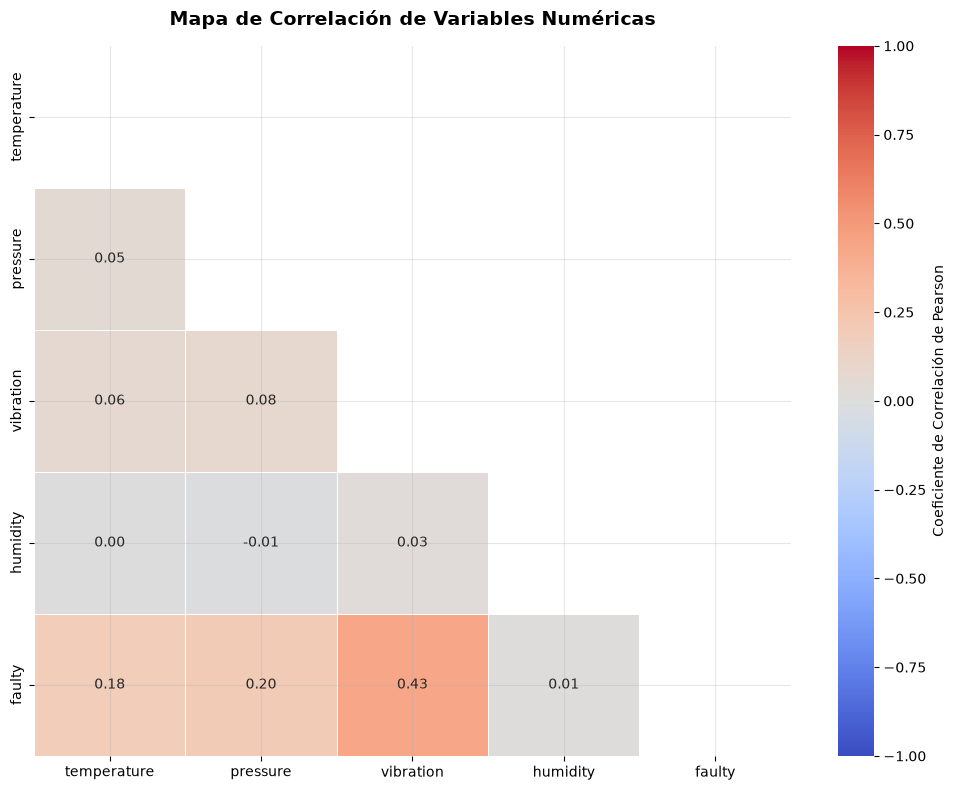

In [27]:
import seaborn as sns

# 1. Cargar el conjunto de datos (asegúrate de colocar el nombre correcto de tu archivo)
# Si es un archivo CSV, usa pd.read_csv('tu_archivo.csv')
#df = pd.read_excel('datos_produccion_limpios.xlsx')

# 2. Seleccionar únicamente las columnas numéricas para el análisis
columnas_numericas = df.select_dtypes(include=[np.number])

# 3. Calcular la matriz de correlación
matriz_corr = columnas_numericas.corr()

# 4. Configurar el tamaño de la figura para una visualización óptima
plt.figure(figsize=(10, 8))

# Crear una máscara para ocultar la mitad superior repetida de la matriz (opcional, para mayor limpieza visual)
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Generar el mapa de calor (Heatmap)
sns.heatmap(
    matriz_corr, 
    mask=mascara, 
    annot=True,          # Muestra los valores numéricos dentro de cada celda
    fmt='.2f',           # Formato de dos decimales
    cmap='coolwarm',     # Paleta de colores (azul para negativo, rojo para positivo)
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,      # Líneas divisorias entre celdas
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

plt.title('Mapa de Correlación de Variables Numéricas', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Guardar la imagen en alta calidad
plt.savefig('mapa_correlacion_completo.png', dpi=300)
plt.show()

In [28]:
df.describe()

,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


## Procesamiento de Datos

In [29]:
# Columnas numéricas de interes para el análisis
num_cols = ['temperature', 'pressure', 'vibration', 'humidity']

In [30]:
df_processed = pd.get_dummies(df, columns=['equipment', 'location'], drop_first=True)

In [31]:
df_processed.head()

,temperature,pressure,vibration,humidity,faulty,equipment_Pump,equipment_Turbine,location_Chicago,location_Houston,location_New York,location_San Francisco
0,58.180180,25.029278,0.606516,45.694907,0.0,False,True,False,False,False,False
1,75.740712,22.954018,2.338095,41.867407,0.0,False,False,True,False,False,False
2,71.358594,27.276830,1.389198,58.954409,0.0,False,True,False,False,False,True
3,71.616985,32.242921,1.770690,40.565138,0.0,True,False,False,False,False,False
4,66.506832,45.197471,0.345398,43.253795,0.0,True,False,False,False,True,False


In [32]:
X = df_processed.drop('faulty', axis=1)
y = df_processed['faulty']

In [33]:
# convertir a numpy arrays para compatibilidad con TensorFlow
print(type(X))

Xarray = X.to_numpy().astype('float32')
print(type(Xarray))
print(Xarray.shape)

Yarray = y.to_numpy().astype('float32')
print(type(Yarray))
print(Yarray.shape)

<class 'pandas.DataFrame'>
<class 'numpy.ndarray'>
(7672, 10)
<class 'numpy.ndarray'>
(7672,)


## Bloque 1 -- El problema de la generalización

El instinto inicial es partir los datos en dos: 80 % entrena, 20 % evalúa. El problema es que
ese 20 % es **una muestra aleatoria**, y por lo tanto la métrica que produce **también es una
variable aleatoria**. Si repetimos la partición cambiando la semilla, obtenemos números
distintos. La pregunta de clase es: *¿qué tan distintos?*

> **Pregunta para los alumnos antes de correr la celda:** si el AUC "real" del modelo es 0.85,
> ¿cuánto creen que puede variar el AUC medido con un solo split de 800 registros? ¿±0.01? ¿±0.05?

## Sin escala

aucs = []
for semilla in range(40):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=semilla, stratify=y
    )
    modelo = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
    aucs.append(roc_auc_score(y_te, modelo.predict_proba(X_te)[:, 1]))

aucs = np.array(aucs)
print(f"AUC mínimo : {aucs.min():.4f}")
print(f"AUC máximo : {aucs.max():.4f}")
print(f"Media      : {aucs.mean():.4f}")
print(f"Desv. est. : {aucs.std():.4f}")
print(f"Rango      : {aucs.max() - aucs.min():.4f}  <-- misma data, mismo modelo")

In [34]:
## Con escala

In [35]:
aucs = []

for semilla in range(40):
    # Separar en entrenamiento y prueba con estratificación
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=semilla, stratify=y
    )
    
    # 4. Escalar los datos correctamente (fit solo en train, transform en train y test)
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    # 5. Entrenar el modelo de Regresión Logística
    modelo = LogisticRegression(max_iter=2000)
    modelo.fit(X_tr_scaled, y_tr)
    
    # 6. Evaluar y guardar el AUC en el conjunto de prueba
    score_auc = roc_auc_score(y_te, modelo.predict_proba(X_te_scaled)[:, 1])
    aucs.append(score_auc)

# 7. Convertir a arreglo de NumPy para calcular métricas estadísticas
aucs = np.array(aucs)

# 8. Mostrar los resultados finales
print(f"AUC mínimo : {aucs.min():.4f}")
print(f"AUC máximo : {aucs.max():.4f}")
print(f"Media      : {aucs.mean():.4f}")
print(f"Desv. est. : {aucs.std():.4f}")
print(f"Rango      : {aucs.max() - aucs.min():.4f} <-- misma data, mismo modelo")

AUC mínimo : 0.7117
AUC máximo : 0.8030
Media      : 0.7627
Desv. est. : 0.0211
Rango      : 0.0913 <-- misma data, mismo modelo


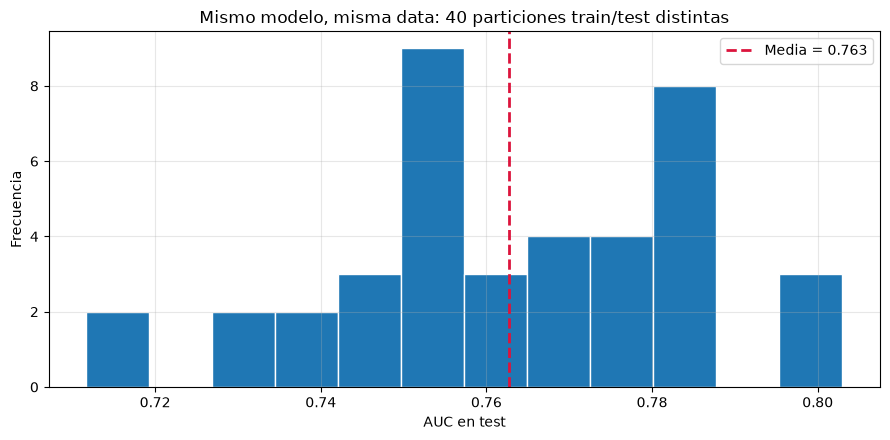

In [37]:
fig, ax = plt.subplots()
ax.hist(aucs, bins=12, edgecolor="white")
ax.axvline(aucs.mean(), color="crimson", ls="--", lw=2, label=f"Media = {aucs.mean():.3f}")
ax.set_title("Mismo modelo, misma data: 40 particiones train/test distintas")
ax.set_xlabel("AUC en test")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

## Lectura del resultado
Cambiando únicamente la semilla, el AUC se mueve varios puntos. Si un analista reporta
"mi modelo tiene 0.87 de AUC" con un solo split, **está reportando un punto de esa
distribución, probablemente el que más le gustó**.

La validación cruzada resuelve esto: en vez de un número, obtenemos una **media y una
desviación**, es decir, una estimación con su incertidumbre.


## Bloque 2  K-Fold Cross Validation

**K-Fold** divide el dataset en $k$ particiones (*folds*) del mismo tamaño. Se entrena $k$ veces:
en cada iteración un fold distinto actúa como validación y los $k-1$ restantes como
entrenamiento. El resultado es un vector de $k$ métricas.

$$\text{CV}_{(k)} = \frac{1}{k}\sum_{i=1}^{k} \text{métrica}_i$$

**Ventajas:** cada observación se usa exactamente una vez para validar; la estimación tiene
mucha menos varianza; obtenemos una barra de error.

**Costo:** entrenar $k$ veces. Con $k=5$ el costo computacional se multiplica por 5.

**¿Qué valor de k?** En la práctica 5 o 10. Con $k$ muy alto (ej. Leave-One-Out, $k=n$) el
sesgo baja pero la varianza sube y el costo se dispara.

In [38]:
# Paso 1: ver los índices "a mano" para que quede claro qué hace K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"{'Fold':<6}{'N entrenamiento':>18}{'N validación':>15}   Primeros índices de validación")
for i, (idx_tr, idx_va) in enumerate(kf.split(X), start=1):
    print(f"{i:<6}{len(idx_tr):>18,}{len(idx_va):>15,}   {idx_va[:5]}")

Fold     N entrenamiento   N validación   Primeros índices de validación
1                  6,137          1,535   [ 0  8 14 17 19]
2                  6,137          1,535   [12 15 26 29 30]
3                  6,138          1,534   [ 6 18 24 25 32]
4                  6,138          1,534   [ 1  2  7 10 11]
5                  6,138          1,534   [ 3  4  5  9 16]


In [39]:
# Paso 2: la forma corta
modelo = LogisticRegression(max_iter=2000)
scores = cross_val_score(modelo, X, y, cv=kf, scoring="roc_auc")

print("AUC por fold:", np.round(scores, 4))
print(f"\nAUC = {scores.mean():.4f} ± {scores.std():.4f}")
print(f"IC aproximado 95%: [{scores.mean() - 2*scores.std():.4f}, {scores.mean() + 2*scores.std():.4f}]")

AUC por fold: [0.7778 0.7419 0.8082 0.7222 0.7827]

AUC = 0.7666 ± 0.0306
IC aproximado 95%: [0.7053, 0.8278]


### `cross_validate`: varias métricas de una sola pasada

`cross_val_score` devuelve una métrica. `cross_validate` devuelve varias, más los tiempos, y
opcionalmente el score de entrenamiento — **que es clave para detectar overfitting**.

In [40]:
resultados = cross_validate(
    LogisticRegression(max_iter=2000),
    X, y, cv=kf,
    scoring=["roc_auc", "average_precision", "f1", "recall", "precision"],
    return_train_score=True,
)

tabla = pd.DataFrame({
    "Métrica": ["roc_auc", "average_precision", "f1", "recall", "precision"],
    "Train": [resultados[f"train_{m}"].mean() for m in
              ["roc_auc", "average_precision", "f1", "recall", "precision"]],
    "Validación": [resultados[f"test_{m}"].mean() for m in
                   ["roc_auc", "average_precision", "f1", "recall", "precision"]],
    "Desv. val.": [resultados[f"test_{m}"].std() for m in
                   ["roc_auc", "average_precision", "f1", "recall", "precision"]],
}).round(4)
tabla["Gap (train - val)"] = (tabla["Train"] - tabla["Validación"]).round(4)
tabla

,Métrica,Train,Validación,Desv. val.,Gap (train - val)
0,roc_auc,0.7701,0.7666,0.0306,0.0035
1,average_precision,0.6410,0.6399,0.0253,0.0011
2,f1,0.5718,0.5649,0.0246,0.0069
3,recall,0.4025,0.3966,0.0236,0.0059
4,precision,0.9873,0.9836,0.0106,0.0037


### Comparar modelos correctamente

Regla: **los modelos se comparan sobre los mismos folds**. Si cada modelo se evalúa con una
partición distinta, la diferencia observada puede deberse a la partición y no al modelo.

In [41]:
candidatos = {
    "Regresión Logística": Pipeline([("sc", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000))]),
    "Árbol (prof. 3)": DecisionTreeClassifier(max_depth=3, random_state=SEED),
    "Árbol (sin podar)": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
}

comparacion = []
for nombre, mod in candidatos.items():
    s = cross_val_score(mod, X, y, cv=kf, scoring="roc_auc")  # mismo objeto kf para todos
    comparacion.append({"Modelo": nombre, "AUC medio": s.mean(), "Desv.": s.std(),
                        "Peor fold": s.min(), "Mejor fold": s.max()})

df_comp = pd.DataFrame(comparacion).sort_values("AUC medio", ascending=False).round(4)
df_comp

,Modelo,AUC medio,Desv.,Peor fold,Mejor fold
3,Random Forest,0.9787,0.0068,0.9697,0.9896
2,Árbol (sin podar),0.9245,0.0070,0.9187,0.9379
1,Árbol (prof. 3),0.8780,0.0220,0.8574,0.9186
0,Regresión Logística,0.7665,0.0306,0.7221,0.8082


# Resumen de Comparativa de Modelos (Validación Cruzada)

La siguiente tabla resume el rendimiento de los modelos evaluados según su **AUC medio**, estabilidad (**Desviación estándar**) y sus extremos por *fold*[cite: 8]:

| Modelo | AUC medio | Desv. | Peor fold | Mejor fold |
| :--- | :---: | :---: | :---: | :---: |
| **Random Forest** | **0.9787** | **0.0068** | 0.9697 | 0.9896 |
| **Árbol (sin podar)** | 0.9245 | 0.0070 | 0.9187 | 0.9379 |
| **Árbol (prof. 3)** | 0.8780 | 0.0220 | 0.8574 | 0.9186 |
| **Regresión Logística** | 0.7665 | 0.0306 | 0.7221 | 0.8082 |

## Conclusiones clave:
1. **Mejor Modelo:** **Random Forest** domina ampliamente con un **AUC de 0.9787** y la menor dispersión (desviación de 0.0068), demostrando máxima precisión y estabilidad[cite: 8].
2. **Árboles de Decisión:** Superan significativamente a la Regresión Logística, aunque el árbol sin restricciones muestra indicios de posible sobreajuste frente a configuraciones más controladas.
3. **Regresión Logística:** Queda rezagada como el modelo base con el rendimiento más bajo (AUC de 0.7665) y mayor variabilidad entre particiones[cite: 8].